Shape of dataset: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



Missing values by column:
Age                         0
StandardHours               0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
MonthlyIncome               0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
MonthlyRate                 0
MaritalStatus               0
Attrition                   0
EmployeeCount               0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
JobSatisfaction             0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel     

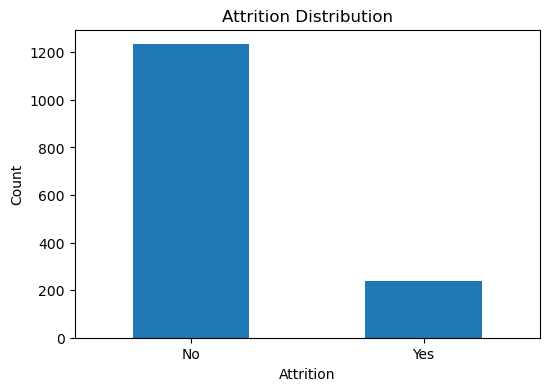


JobRole counts:
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64


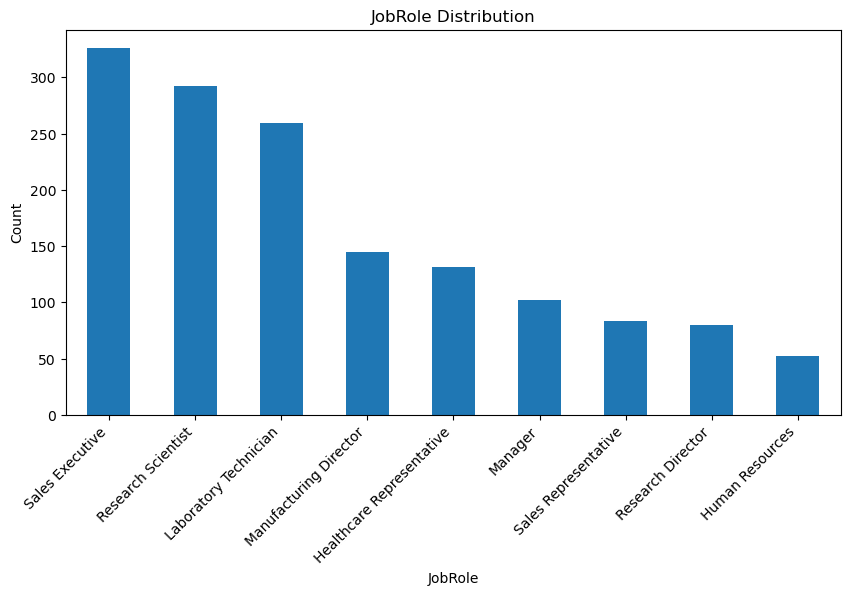


MonthlyIncome summary by JobRole:


,mean,median,min,max,count
JobRole,,,,,
Healthcare Representative,7528.763359,6811.0,4000,13966,131
Human Resources,4235.750000,3093.0,1555,10725,52
Laboratory Technician,3237.169884,2886.0,1102,7403,259
Manager,17181.676471,17454.5,11244,19999,102
Manufacturing Director,7295.137931,6447.0,4011,13973,145
Research Director,16033.550000,16510.0,11031,19973,80
Research Scientist,3239.972603,2887.5,1009,9724,292
Sales Executive,6924.279141,6231.0,4001,13872,326
Sales Representative,2626.000000,2579.0,1052,6632,83



Shape after dropping unused columns: (1470, 31)

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [1]:
# =========================================================
# FINAL CLEAN VERSION
# Section 1. Data loading and initial screening
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("IBM-HR-Employee-Attrition.csv")

# Basic information
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

# Missing values
print("\nMissing values by column:")
print(df.isnull().sum().sort_values(ascending=False))

# Attrition distribution
print("\nAttrition distribution:")
print(df["Attrition"].value_counts())

plt.figure(figsize=(6, 4))
df["Attrition"].value_counts().plot(kind="bar")
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# JobRole distribution
print("\nJobRole counts:")
print(df["JobRole"].value_counts())

plt.figure(figsize=(10, 5))
df["JobRole"].value_counts().plot(kind="bar")
plt.title("JobRole Distribution")
plt.xlabel("JobRole")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Salary summary by JobRole
salary_stats = df.groupby("JobRole")["MonthlyIncome"].agg(["mean", "median", "min", "max", "count"])
print("\nMonthlyIncome summary by JobRole:")
display(salary_stats)

# Drop invalid / non-informative columns
drop_cols = [
    "EmployeeNumber",   # ID variable
    "EmployeeCount",    # constant column
    "Over18",           # constant column
    "StandardHours"     # constant column
]

df = df.drop(columns=drop_cols)

print("\nShape after dropping unused columns:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

In [2]:
# =========================================================
# Section 1B. Exploratory check for JobLevel vs experience
# =========================================================

joblevel_exp = df.groupby("JobLevel")["TotalWorkingYears"].agg(
    ["count", "mean", "median", "min", "max"]
)
print("TotalWorkingYears by JobLevel:")
display(joblevel_exp)

jobrole_joblevel_exp = (
    df.groupby(["JobRole", "JobLevel"])["TotalWorkingYears"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

print("\nTotalWorkingYears by JobRole and JobLevel:")
display(jobrole_joblevel_exp)

TotalWorkingYears by JobLevel:


,count,mean,median,min,max
JobLevel,,,,,
1,543,5.891344,6.0,0,20
2,534,10.423221,10.0,4,20
3,218,15.119266,13.0,9,40
4,106,25.471698,25.0,9,38
5,69,26.376812,25.0,21,40



TotalWorkingYears by JobRole and JobLevel:


,JobRole,JobLevel,count,mean,median,min,max
0,Healthcare Representative,2,78,11.141026,10.0,4,20
1,Healthcare Representative,3,44,16.772727,15.5,9,40
2,Healthcare Representative,4,9,26.222222,25.0,21,34
3,Human Resources,1,33,5.666667,6.0,1,13
4,Human Resources,2,13,12.230769,12.0,9,19
5,Human Resources,3,6,13.166667,10.5,9,24
6,Laboratory Technician,1,200,6.280000,6.0,0,20
7,Laboratory Technician,2,56,11.625000,10.0,5,20
8,Laboratory Technician,3,3,25.333333,24.0,23,29
9,Manager,3,12,12.500000,13.0,9,16


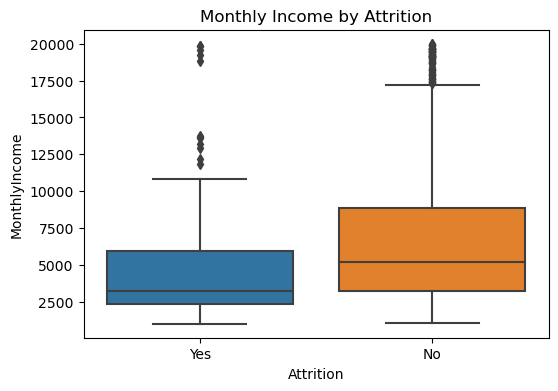

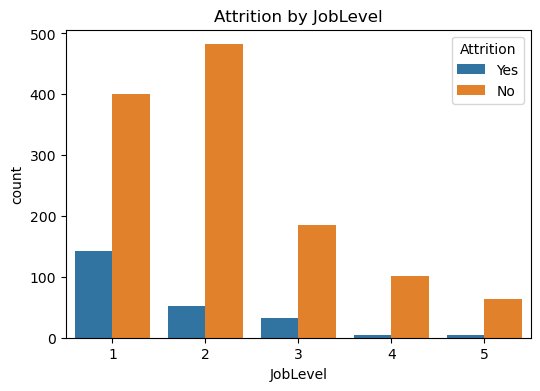

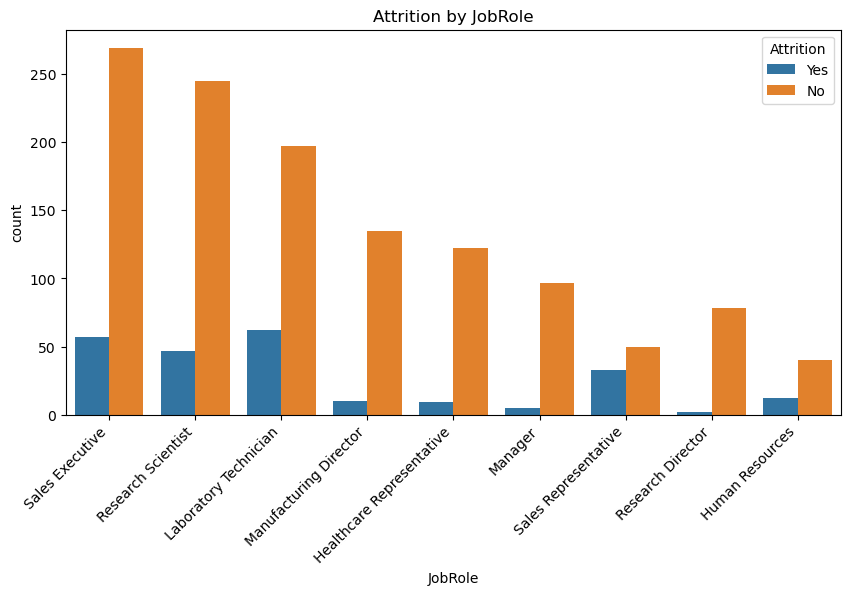

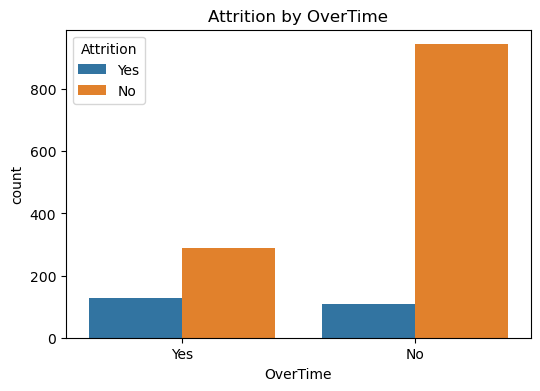

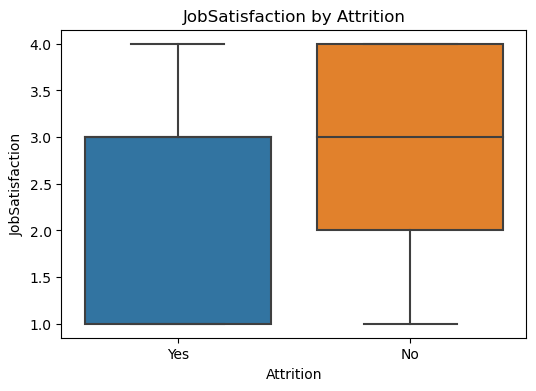

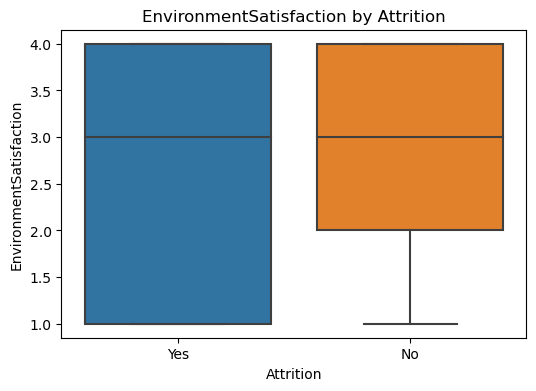

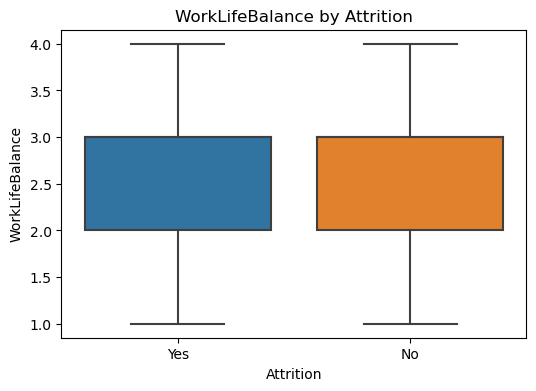

In [3]:
# =========================================================
# Section 1C. Exploratory Data Analysis (Pre-construction)
# =========================================================

import seaborn as sns

# This section provides descriptive exploration of key raw variables
# before treatment construction.

# ------------------------------------------
# 1. Attrition vs MonthlyIncome
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income by Attrition")
plt.show()

# ------------------------------------------
# 2. JobLevel vs Attrition
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x="JobLevel", hue="Attrition", data=df)
plt.title("Attrition by JobLevel")
plt.show()

# ------------------------------------------
# 3. JobRole vs Attrition
# ------------------------------------------
plt.figure(figsize=(10, 5))
sns.countplot(x="JobRole", hue="Attrition", data=df)
plt.xticks(rotation=45, ha="right")
plt.title("Attrition by JobRole")
plt.show()

# ------------------------------------------
# 4. OverTime vs Attrition
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition by OverTime")
plt.show()

# ------------------------------------------
# 5. Satisfaction variables vs Attrition
# ------------------------------------------
satisfaction_vars = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance"
]

for var in satisfaction_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Attrition", y=var, data=df)
    plt.title(f"{var} by Attrition")
    plt.show()

In [4]:
# =========================================================
# Section 2. Variable construction
# =========================================================

# Outcome variable: Attrition -> binary
df["Attrition_binary"] = df["Attrition"].map({"Yes": 1, "No": 0})

print("Attrition_binary distribution:")
print(df["Attrition_binary"].value_counts())

# Binary variable: OverTime -> 0/1
df["OverTime_binary"] = df["OverTime"].map({"Yes": 1, "No": 0})

print("\nOverTime_binary distribution:")
print(df["OverTime_binary"].value_counts())

# External market salary benchmark using Glassdoor base pay midpoint (annual USD)
market_salary_dict = {
    "Healthcare Representative": 67500,   # (51k + 84k)/2
    "Human Resources": 84500,             # (60k + 109k)/2
    "Laboratory Technician": 55000,       # (45k + 65k)/2
    "Manager": 83000,                     # (60k + 106k)/2
    "Manufacturing Director": 121500,     # (91k + 152k)/2
    "Research Director": 159500,          # (116k + 203k)/2
    "Research Scientist": 154500,         # (122k + 187k)/2
    "Sales Executive": 90000,             # (63k + 117k)/2
    "Sales Representative": 78500         # (60k + 97k)/2
}

# Map benchmark to dataset
df["MarketSalary_external_annual"] = df["JobRole"].map(market_salary_dict)
df["MarketSalary_external_monthly"] = df["MarketSalary_external_annual"] / 12

# Check whether any JobRole failed to match
missing_benchmark = df["MarketSalary_external_monthly"].isnull().sum()
print(f"\nNumber of missing external benchmark values: {missing_benchmark}")

print("\nExternal market benchmark preview:")
display(
    df[["JobRole", "MonthlyIncome", "MarketSalary_external_annual", "MarketSalary_external_monthly"]]
    .drop_duplicates(subset=["JobRole"])
    .sort_values("JobRole")
    .reset_index(drop=True)
)

print("\nExternal market benchmark summary (monthly):")
print(df["MarketSalary_external_monthly"].describe())

Attrition_binary distribution:
Attrition_binary
0    1233
1     237
Name: count, dtype: int64

OverTime_binary distribution:
OverTime_binary
0    1054
1     416
Name: count, dtype: int64

Number of missing external benchmark values: 0

External market benchmark preview:


,JobRole,MonthlyIncome,MarketSalary_external_annual,MarketSalary_external_monthly
0,Healthcare Representative,5237,67500,5625.000000
1,Human Resources,5021,84500,7041.666667
2,Laboratory Technician,2090,55000,4583.333333
3,Manager,15427,83000,6916.666667
4,Manufacturing Director,9526,121500,10125.000000
5,Research Director,11994,159500,13291.666667
6,Research Scientist,5130,154500,12875.000000
7,Sales Executive,5993,90000,7500.000000
8,Sales Representative,3407,78500,6541.666667



External market benchmark summary (monthly):
count     1470.000000
mean      8350.028345
std       3069.673615
min       4583.333333
25%       5625.000000
50%       7500.000000
75%      12875.000000
max      13291.666667
Name: MarketSalary_external_monthly, dtype: float64


SalaryRatio summary:
count    1470.000000
mean        0.851480
std         0.616292
min         0.078369
25%         0.420380
50%         0.700115
75%         1.101367
max         2.891422
Name: SalaryRatio, dtype: float64

SalaryRatio percentiles:
0.01    0.157472
0.05    0.183880
0.50    0.700115
0.95    2.418247
0.99    2.812976
Name: SalaryRatio, dtype: float64

SalaryRatio_winsorized summary:
count    1470.000000
mean        0.851417
std         0.614539
min         0.157472
25%         0.420380
50%         0.700115
75%         1.101367
max         2.812976
Name: SalaryRatio_winsorized, dtype: float64


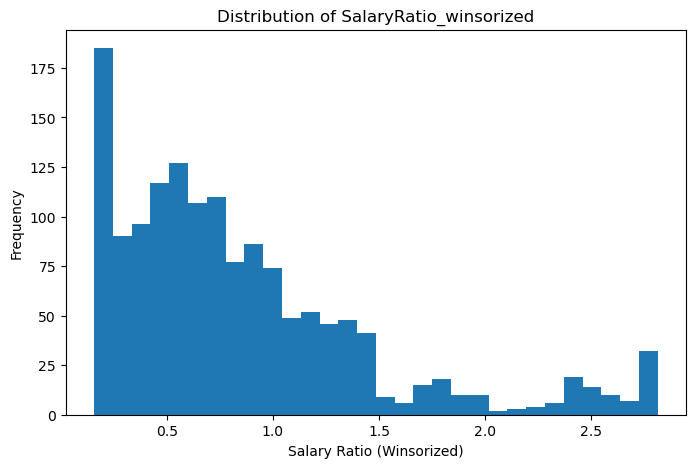

In [5]:
# =========================================================
# Section 3. Treatment benchmark matching
# =========================================================

# Construct treatment variable: salary-market alignment ratio
df["SalaryRatio"] = df["MonthlyIncome"] / df["MarketSalary_external_monthly"]

print("SalaryRatio summary:")
print(df["SalaryRatio"].describe())

print("\nSalaryRatio percentiles:")
print(df["SalaryRatio"].quantile([0.01, 0.05, 0.50, 0.95, 0.99]))

# Winsorize the treatment variable
lower = df["SalaryRatio"].quantile(0.01)
upper = df["SalaryRatio"].quantile(0.99)

df["SalaryRatio_winsorized"] = df["SalaryRatio"].clip(lower=lower, upper=upper)

print("\nSalaryRatio_winsorized summary:")
print(df["SalaryRatio_winsorized"].describe())

# Plot treatment distribution
plt.figure(figsize=(8, 5))
plt.hist(df["SalaryRatio_winsorized"], bins=30)
plt.title("Distribution of SalaryRatio_winsorized")
plt.xlabel("Salary Ratio (Winsorized)")
plt.ylabel("Frequency")
plt.show()

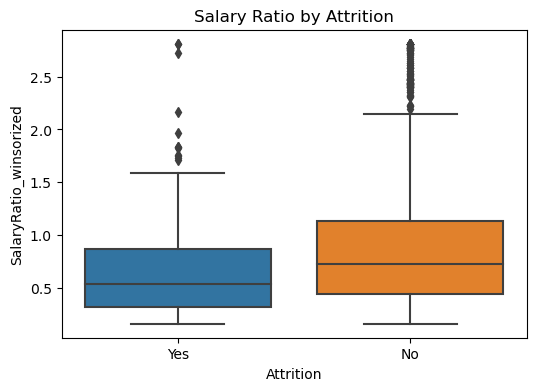

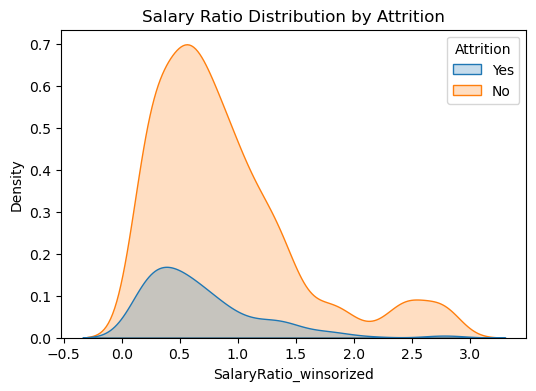

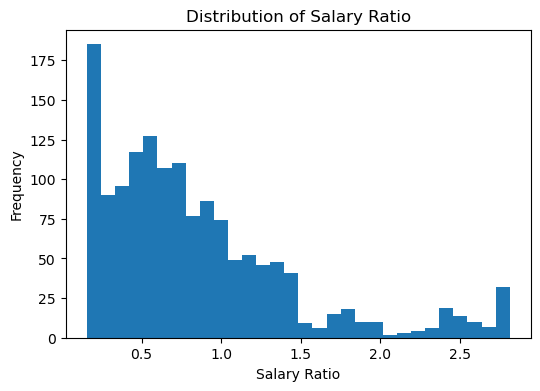

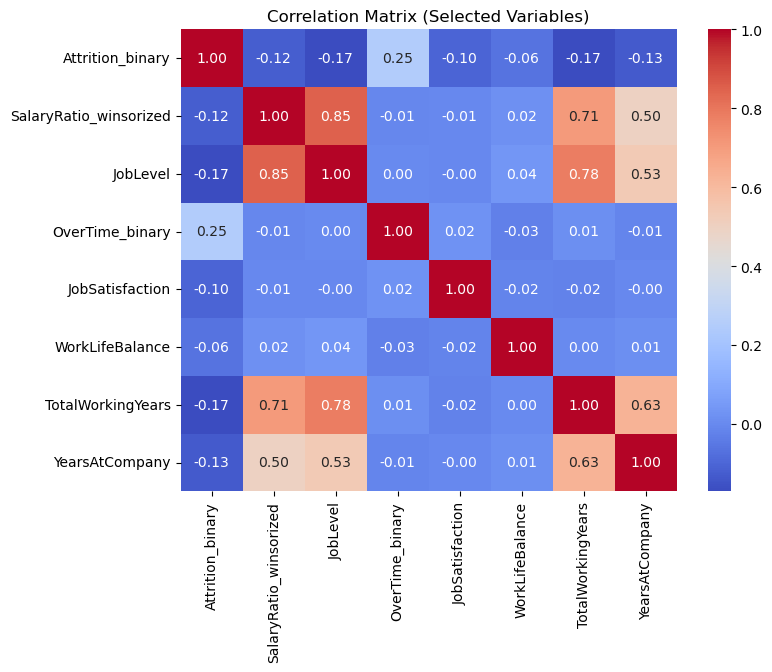

In [6]:
# =========================================================
# Section 3B. Exploratory analysis of SalaryRatio
# =========================================================

# ------------------------------------------
# 1. SalaryRatio vs Attrition
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.boxplot(x="Attrition", y="SalaryRatio_winsorized", data=df)
plt.title("Salary Ratio by Attrition")
plt.show()

# ------------------------------------------
# 2. SalaryRatio distribution by Attrition
# ------------------------------------------
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x="SalaryRatio_winsorized", hue="Attrition", fill=True)
plt.title("Salary Ratio Distribution by Attrition")
plt.show()

# ------------------------------------------
# 3. SalaryRatio overall distribution
# ------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(df["SalaryRatio_winsorized"], bins=30)
plt.title("Distribution of Salary Ratio")
plt.xlabel("Salary Ratio")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# 4. Correlation matrix (selected variables)
# ------------------------------------------
selected_vars = [
    "Attrition_binary",
    "SalaryRatio_winsorized",
    "JobLevel",
    "OverTime_binary",
    "JobSatisfaction",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsAtCompany"
]

corr = df[selected_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Selected Variables)")
plt.show()

In [7]:
# =========================================================
# Section 4. Data preprocessing (UPDATED - include JobRole)
# =========================================================

from sklearn.preprocessing import StandardScaler

# Quick check of key variables
print(df[["Attrition_binary", "OverTime_binary", "SalaryRatio_winsorized"]].head())
print("\nMissing values in key variables:")
print(df[["Attrition_binary", "OverTime_binary", "SalaryRatio_winsorized"]].isnull().sum())

# Covariates (NOW INCLUDING JobRole)
X_cols = [
    "Age",
    "JobLevel",
    "YearsAtCompany",
    "OverTime_binary",
    "StockOptionLevel",
    "PerformanceRating",
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "JobRole"   # ⭐ NEW (IMPORTANT)
]

# Define outcome and treatment
Y = df["Attrition_binary"].values
T = df["SalaryRatio_winsorized"].values

# Build X
X = df[X_cols].copy()

# 🔥 One-hot encode JobRole
X = pd.get_dummies(X, columns=["JobRole"], drop_first=True, dtype=int)

print("\nX after adding JobRole dummies:")
print(X.shape)
display(X.head())

# Standardize continuous variables ONLY
continuous_cols = [
    "Age",
    "YearsAtCompany",
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])

print("\nScaled covariates preview:")
display(X_scaled.head())

   Attrition_binary  OverTime_binary  SalaryRatio_winsorized
0                 1                1                0.799067
1                 0                0                0.398447
2                 1                1                0.456000
3                 0                1                0.225942
4                 0                0                0.756655

Missing values in key variables:
Attrition_binary          0
OverTime_binary           0
SalaryRatio_winsorized    0
dtype: int64

X after adding JobRole dummies:
(1470, 23)


,Age,JobLevel,YearsAtCompany,OverTime_binary,StockOptionLevel,PerformanceRating,TotalWorkingYears,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,JobSatisfaction,EnvironmentSatisfaction,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,41,2,6,1,0,3,8,4,0,5,...,4,2,0,0,0,0,0,0,1,0
1,49,2,10,0,1,4,10,7,1,7,...,2,3,0,0,0,0,0,1,0,0
2,37,1,0,1,0,3,7,0,0,0,...,3,4,0,1,0,0,0,0,0,0
3,33,1,8,1,0,3,8,7,3,0,...,3,4,0,0,0,0,0,1,0,0
4,27,1,2,0,1,3,6,2,2,2,...,2,1,0,1,0,0,0,0,0,0



Scaled covariates preview:


,Age,JobLevel,YearsAtCompany,OverTime_binary,StockOptionLevel,PerformanceRating,TotalWorkingYears,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,JobSatisfaction,EnvironmentSatisfaction,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative
0,0.446350,2,-0.164613,1,0,3,-0.421642,-0.063296,-0.679146,0.245834,...,4,2,0,0,0,0,0,0,1,0
1,1.322365,2,0.488508,0,1,4,-0.164511,0.764998,-0.368715,0.806541,...,2,3,0,0,0,0,0,1,0,0
2,0.008343,1,-1.144294,1,0,3,-0.550208,-1.167687,-0.679146,-1.155935,...,3,4,0,1,0,0,0,0,0,0
3,-0.429664,1,0.161947,1,0,3,-0.421642,0.764998,0.252146,-1.155935,...,3,4,0,0,0,0,0,1,0,0
4,-1.086676,1,-0.817734,0,1,3,-0.678774,-0.615492,-0.058285,-0.595227,...,2,1,0,1,0,0,0,0,0,0


CausalForestDML model fitted successfully.
Treatment variable: SalaryRatio_winsorized
Key control variables included: JobLevel and JobRole (as confounders)

CATE summary:
count    1470.000000
mean       -0.022906
std         0.071264
min        -0.276134
25%        -0.062649
50%        -0.015313
75%         0.023111
max         0.261129
Name: CATE, dtype: float64

Average estimated treatment effect: -0.022905548750157188
Effect of 10% increase in salary ratio: -0.002290554875015719
ATE 95% confidence interval: (-0.24709949399241302, 0.2012883964920986)


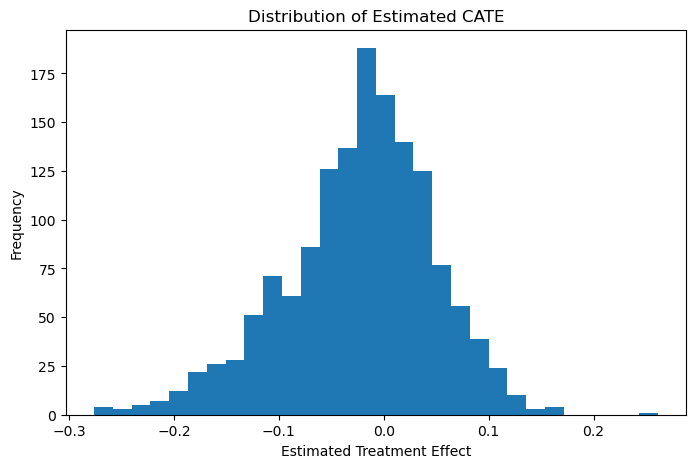

In [8]:
# =========================================================
# Section 5. Main causal estimation: CausalForestDML
# =========================================================

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

# JobLevel is included in X to account for internal hierarchy differences

# Outcome model
model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# Treatment model
model_t = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

# Causal forest model
cf = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    n_estimators=500,
    min_samples_leaf=10,
    max_depth=10,
    discrete_treatment=False,
    cv=3,
    random_state=42,
    n_jobs=-1
)

# Fit model
cf.fit(Y, T, X=X_scaled)

print("CausalForestDML model fitted successfully.")
print("Treatment variable: SalaryRatio_winsorized")
print("Key control variables included: JobLevel and JobRole (as confounders)")

# Estimated individual treatment effects (CATE)
cate = cf.effect(X_scaled)
df["CATE"] = cate

print("\nCATE summary:")
print(df["CATE"].describe())

# Average estimated treatment effect (ATE)
ate = np.mean(cate)
print("\nAverage estimated treatment effect:", ate)

# More interpretable scale: 10% increase in salary ratio
ate_10pct = ate * 0.1
print("Effect of 10% increase in salary ratio:", ate_10pct)

# Confidence interval
try:
    ate_interval = cf.ate_interval(X=X_scaled)
    print("ATE 95% confidence interval:", ate_interval)
except Exception as e:
    print("ATE interval not available in current setup:", e)

# Plot CATE distribution
plt.figure(figsize=(8, 5))
plt.hist(df["CATE"], bins=30)
plt.title("Distribution of Estimated CATE")
plt.xlabel("Estimated Treatment Effect")
plt.ylabel("Frequency")
plt.show()

CATE summary by JobRole (with significance):


,mean,std,count,p_value
JobRole,,,,
Sales Representative,-0.079105,0.070961,83,3.673651e-16
Laboratory Technician,-0.051902,0.079190,259,7.342978e-22
Research Scientist,-0.042924,0.070241,292,6.883094e-22
Human Resources,-0.024424,0.070413,52,1.562477e-02
Manufacturing Director,-0.012897,0.047813,145,1.446014e-03
Healthcare Representative,-0.005333,0.059704,131,3.084679e-01
Manager,-0.004685,0.053636,102,3.798205e-01
Research Director,-0.000404,0.054443,80,9.472360e-01
Sales Executive,0.009877,0.064377,326,5.924525e-03



CATE summary by JobRoleCluster (with significance):


,mean,std,count,p_value
JobRoleCluster,,,,
Technical,-0.041218,0.074017,631,6.447436e-39
Support,-0.010758,0.063324,183,2.268600e-02
Managerial,-0.009506,0.050356,247,3.306753e-03
Sales,-0.008180,0.074814,409,2.756772e-02



CATE summary by MarketPressureGroup (with significance):


,mean,std,count,p_value
MarketPressureGroup,,,,
High Pressure,-0.042431,0.075180,735,4.454216e-46
Low Pressure,-0.003380,0.061225,735,1.348811e-01



CATE summary by JobLevel (with significance):


,mean,std,count,p_value
JobLevel,,,,
1,-0.061172,0.074754,543,2.062098e-62
5,-0.007244,0.056365,69,2.894985e-01
2,-0.002871,0.061264,534,2.793444e-01
4,0.002454,0.051068,106,6.218586e-01
3,0.006046,0.055315,218,1.080352e-01


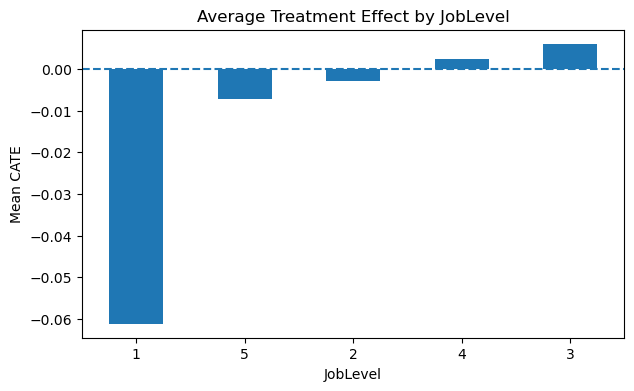

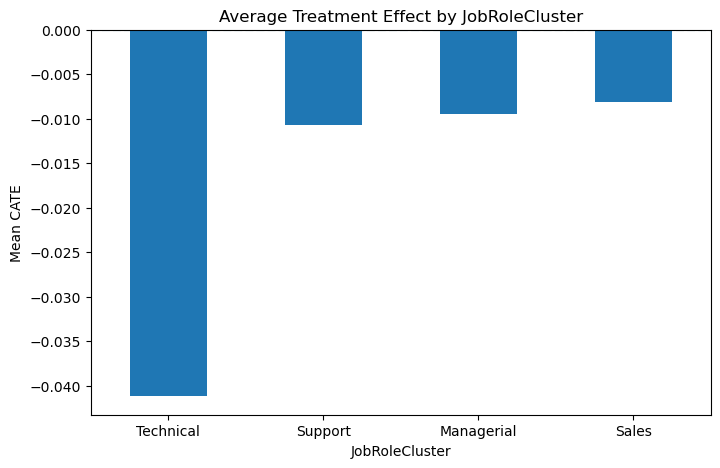

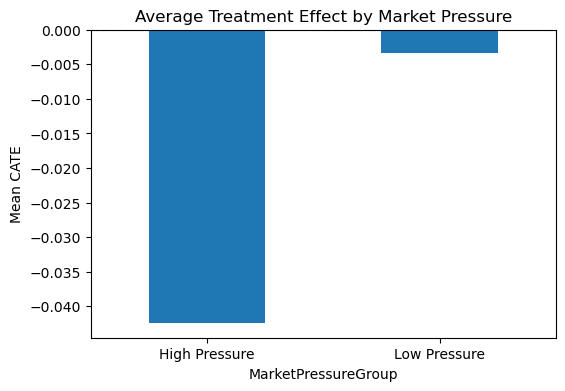

In [9]:
# =========================================================
# Section 6. Heterogeneous treatment effect analysis
# =========================================================

from scipy.stats import ttest_1samp
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# 1. Heterogeneity by JobRole
# ------------------------
jobrole_cate = (
    df.groupby("JobRole")["CATE"]
    .agg(["mean", "std", "count"])
)

# Add t-test p-values
p_values = []
for role in jobrole_cate.index:
    vals = df.loc[df["JobRole"] == role, "CATE"]
    t_stat, p_val = ttest_1samp(vals, popmean=0)
    p_values.append(p_val)

jobrole_cate["p_value"] = p_values
jobrole_cate = jobrole_cate.sort_values("mean")

print("CATE summary by JobRole (with significance):")
display(jobrole_cate)

# ------------------------
# 2. JobRole clusters
# ------------------------
jobrole_cluster_map = {
    "Sales Executive": "Sales",
    "Sales Representative": "Sales",
    "Research Scientist": "Technical",
    "Laboratory Technician": "Technical",
    "Research Director": "Technical",
    "Manufacturing Director": "Managerial",
    "Manager": "Managerial",
    "Healthcare Representative": "Support",
    "Human Resources": "Support"
}

df["JobRoleCluster"] = df["JobRole"].map(jobrole_cluster_map)

cluster_cate = (
    df.groupby("JobRoleCluster")["CATE"]
    .agg(["mean", "std", "count"])
)

# Add p-values
p_values = []
for group in cluster_cate.index:
    vals = df.loc[df["JobRoleCluster"] == group, "CATE"]
    t_stat, p_val = ttest_1samp(vals, popmean=0)
    p_values.append(p_val)

cluster_cate["p_value"] = p_values
cluster_cate = cluster_cate.sort_values("mean")

print("\nCATE summary by JobRoleCluster (with significance):")
display(cluster_cate)

# ------------------------
# 3. Market pressure groups
# ------------------------
median_ratio = df["SalaryRatio_winsorized"].median()

df["MarketPressureGroup"] = np.where(
    df["SalaryRatio_winsorized"] < median_ratio,
    "High Pressure",
    "Low Pressure"
)

pressure_cate = (
    df.groupby("MarketPressureGroup")["CATE"]
    .agg(["mean", "std", "count"])
)

# Add p-values
p_values = []
for group in pressure_cate.index:
    vals = df.loc[df["MarketPressureGroup"] == group, "CATE"]
    t_stat, p_val = ttest_1samp(vals, popmean=0)
    p_values.append(p_val)

pressure_cate["p_value"] = p_values
pressure_cate = pressure_cate.sort_values("mean")

print("\nCATE summary by MarketPressureGroup (with significance):")
display(pressure_cate)

# ------------------------
# 4. Heterogeneity by JobLevel
# ------------------------
joblevel_cate = (
    df.groupby("JobLevel")["CATE"]
    .agg(["mean", "std", "count"])
)

# Add p-values
p_values = []
for level in joblevel_cate.index:
    vals = df.loc[df["JobLevel"] == level, "CATE"]
    t_stat, p_val = ttest_1samp(vals, popmean=0)
    p_values.append(p_val)

joblevel_cate["p_value"] = p_values
joblevel_cate = joblevel_cate.sort_values("mean")

print("\nCATE summary by JobLevel (with significance):")
display(joblevel_cate)

# ------------------------
# 5. Visualization
# ------------------------

# Plot by JobLevel
plt.figure(figsize=(7, 4))
joblevel_cate["mean"].plot(kind="bar")
plt.title("Average Treatment Effect by JobLevel")
plt.ylabel("Mean CATE")
plt.xlabel("JobLevel")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=0)
plt.show()

# Plot by JobRoleCluster
plt.figure(figsize=(8, 5))
cluster_cate["mean"].plot(kind="bar")
plt.title("Average Treatment Effect by JobRoleCluster")
plt.ylabel("Mean CATE")
plt.xlabel("JobRoleCluster")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=0)
plt.show()

# Plot by MarketPressureGroup
plt.figure(figsize=(6, 4))
pressure_cate["mean"].plot(kind="bar")
plt.title("Average Treatment Effect by Market Pressure")
plt.ylabel("Mean CATE")
plt.xlabel("MarketPressureGroup")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=0)
plt.show()

In [10]:
# ------------------------
# 6. Interaction: JobRole × JobLevel (NEW)
# ------------------------

interaction_cate = (
    df.groupby(["JobRole", "JobLevel"])["CATE"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# filter away small samples
interaction_cate = interaction_cate[interaction_cate["count"] >= 20]

print("\nCATE by JobRole × JobLevel (interaction):")
display(interaction_cate.sort_values("mean"))


CATE by JobRole × JobLevel (interaction):


,JobRole,JobLevel,mean,std,count
24,Sales Representative,1,-0.082114,0.066647,76
6,Laboratory Technician,1,-0.065908,0.080489,200
18,Research Scientist,1,-0.053300,0.069795,234
3,Human Resources,1,-0.040054,0.079911,33
12,Manufacturing Director,2,-0.014777,0.053655,90
0,Healthcare Representative,2,-0.011471,0.060344,78
13,Manufacturing Director,3,-0.010787,0.037842,45
11,Manager,5,-0.008032,0.053292,43
17,Research Director,5,-0.005941,0.062189,26
16,Research Director,4,-0.005784,0.055092,26



CATE by JobRoleCluster × JobLevel:


,JobRoleCluster,JobLevel,mean,std,count
4,Sales,1,-0.082114,0.066647,76
12,Technical,1,-0.059110,0.075089,434
8,Support,1,-0.040054,0.079911,33
0,Managerial,2,-0.014777,0.053655,90
1,Managerial,3,-0.011951,0.040832,57
9,Support,2,-0.010010,0.057258,91
3,Managerial,5,-0.008032,0.053292,43
16,Technical,5,-0.005941,0.062189,26
15,Technical,4,-0.005784,0.055092,26
13,Technical,2,-0.001988,0.052343,113


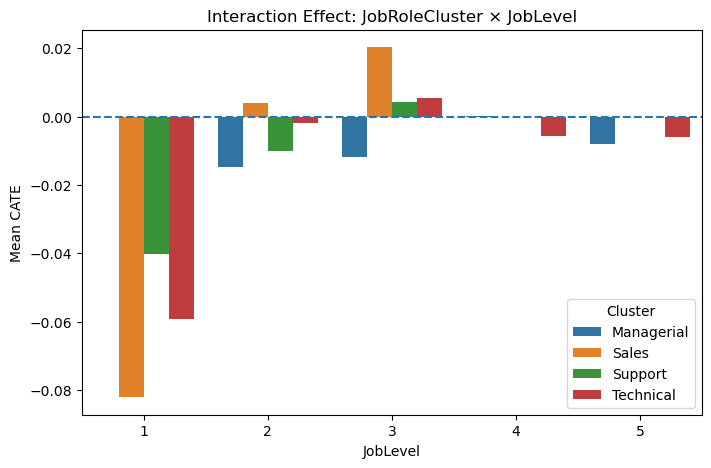

In [11]:
# ------------------------
# 7. Interaction: JobRoleCluster × JobLevel
# ------------------------

interaction_cluster_cate = (
    df.groupby(["JobRoleCluster", "JobLevel"])["CATE"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

interaction_cluster_cate = interaction_cluster_cate[interaction_cluster_cate["count"] >= 20]

print("\nCATE by JobRoleCluster × JobLevel:")
display(interaction_cluster_cate.sort_values("mean"))

# ------------------------
# Visualization: Cluster × JobLevel
# ------------------------

import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=interaction_cluster_cate,
    x="JobLevel",
    y="mean",
    hue="JobRoleCluster"
)

plt.title("Interaction Effect: JobRoleCluster × JobLevel")
plt.ylabel("Mean CATE")
plt.xlabel("JobLevel")
plt.axhline(0, linestyle="--")
plt.legend(title="Cluster")
plt.show()

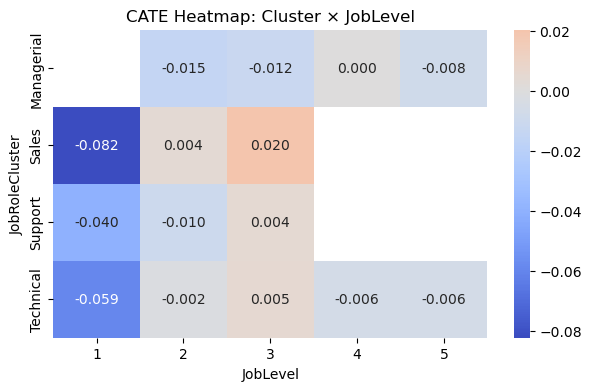

In [12]:
# ------------------------
# Heatmap 
# ------------------------

pivot_table = interaction_cluster_cate.pivot(
    index="JobRoleCluster",
    columns="JobLevel",
    values="mean"
)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="coolwarm", center=0)

plt.title("CATE Heatmap: Cluster × JobLevel")
plt.show()

In [13]:
# =========================================================
# Section 7. Statistical summary tests
# (Subgroup tests only; full-sample t-test removed)
# =========================================================

import pandas as pd
from scipy.stats import ttest_1samp

# ------------------------
# 1. JobRoleCluster tests
# ------------------------
cluster_results = []

for group in sorted(df["JobRoleCluster"].dropna().unique()):
    vals = df.loc[df["JobRoleCluster"] == group, "CATE"]
    t_stat, p_value = ttest_1samp(vals, popmean=0)
    
    cluster_results.append({
        "Group": group,
        "Mean CATE": vals.mean(),
        "Std": vals.std(),
        "N": len(vals),
        "t-stat": t_stat,
        "p-value": p_value
    })

cluster_results_df = pd.DataFrame(cluster_results).sort_values("Mean CATE")

print("JobRoleCluster results:")
display(cluster_results_df)

# ------------------------
# 2. MarketPressureGroup tests
# ------------------------
pressure_results = []

for group in sorted(df["MarketPressureGroup"].dropna().unique()):
    vals = df.loc[df["MarketPressureGroup"] == group, "CATE"]
    t_stat, p_value = ttest_1samp(vals, popmean=0)
    
    pressure_results.append({
        "Group": group,
        "Mean CATE": vals.mean(),
        "Std": vals.std(),
        "N": len(vals),
        "t-stat": t_stat,
        "p-value": p_value
    })

pressure_results_df = pd.DataFrame(pressure_results).sort_values("Mean CATE")

print("\nMarketPressureGroup results:")
display(pressure_results_df)

# ------------------------
# 3. JobLevel tests
# ------------------------
joblevel_results = []

for level in sorted(df["JobLevel"].dropna().unique()):
    vals = df.loc[df["JobLevel"] == level, "CATE"]
    t_stat, p_value = ttest_1samp(vals, popmean=0)
    
    joblevel_results.append({
        "Group": f"Level {level}",
        "Mean CATE": vals.mean(),
        "Std": vals.std(),
        "N": len(vals),
        "t-stat": t_stat,
        "p-value": p_value
    })

joblevel_results_df = pd.DataFrame(joblevel_results).sort_values("Mean CATE")

print("\nJobLevel results:")
display(joblevel_results_df)

JobRoleCluster results:


,Group,Mean CATE,Std,N,t-stat,p-value
3,Technical,-0.041218,0.074017,631,-13.988508,6.447436e-39
2,Support,-0.010758,0.063324,183,-2.298223,2.268600e-02
0,Managerial,-0.009506,0.050356,247,-2.966694,3.306753e-03
1,Sales,-0.008180,0.074814,409,-2.211316,2.756772e-02



MarketPressureGroup results:


,Group,Mean CATE,Std,N,t-stat,p-value
0,High Pressure,-0.042431,0.075180,735,-15.301184,4.454216e-46
1,Low Pressure,-0.003380,0.061225,735,-1.496777,1.348811e-01



JobLevel results:


,Group,Mean CATE,Std,N,t-stat,p-value
0,Level 1,-0.061172,0.074754,543,-19.068589,2.062098e-62
4,Level 5,-0.007244,0.056365,69,-1.067551,2.894985e-01
1,Level 2,-0.002871,0.061264,534,-1.082896,2.793444e-01
3,Level 4,0.002454,0.051068,106,0.494681,6.218586e-01
2,Level 3,0.006046,0.055315,218,1.613749,1.080352e-01


In [14]:
# ------------------------
# 4. Interaction tests: JobRoleCluster × JobLevel
# ------------------------

interaction_results = []

for cluster in df["JobRoleCluster"].dropna().unique():
    for level in df["JobLevel"].dropna().unique():
        
        subset = df[
            (df["JobRoleCluster"] == cluster) &
            (df["JobLevel"] == level)
        ]["CATE"]
        
        # 避免样本太小
        if len(subset) >= 20:
            t_stat, p_value = ttest_1samp(subset, popmean=0)
            
            interaction_results.append({
                "Cluster": cluster,
                "JobLevel": level,
                "Mean CATE": subset.mean(),
                "Std": subset.std(),
                "N": len(subset),
                "t-stat": t_stat,
                "p-value": p_value
            })

interaction_results_df = pd.DataFrame(interaction_results)

print("\nInteraction results (Cluster × JobLevel):")
display(interaction_results_df.sort_values("Mean CATE"))


Interaction results (Cluster × JobLevel):


,Cluster,JobLevel,Mean CATE,Std,N,t-stat,p-value
1,Sales,1,-0.082114,0.066647,76,-10.741024,7.906944e-17
4,Technical,1,-0.059110,0.075089,434,-16.399588,2.317315e-47
13,Support,1,-0.040054,0.079911,33,-2.879378,7.049421e-03
8,Managerial,2,-0.014777,0.053655,90,-2.612750,1.054336e-02
9,Managerial,3,-0.011951,0.040832,57,-2.209746,3.122799e-02
12,Support,2,-0.010010,0.057258,91,-1.667760,9.883934e-02
11,Managerial,5,-0.008032,0.053292,43,-0.988262,3.286840e-01
7,Technical,5,-0.005941,0.062189,26,-0.487148,6.303974e-01
6,Technical,4,-0.005784,0.055092,26,-0.535320,5.971586e-01
3,Technical,2,-0.001988,0.052343,113,-0.403676,6.872204e-01


Predictor feature shape: (1470, 24)
Outcome shape: (1470,)

Train shape: (1029, 24)
Test shape: (441, 24)

RandomForestClassifier fitted successfully.
Train AUC: 0.9378813050580073
Test AUC: 0.7701941377997715

Classification report on test set:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       370
           1       0.40      0.11      0.18        71

    accuracy                           0.83       441
   macro avg       0.63      0.54      0.54       441
weighted avg       0.78      0.83      0.79       441


Raw shap_values shape: (1029, 24, 2)
X_train shape: (1029, 24)
Final shap_matrix shape: (1029, 24)

Generating SHAP summary plot...


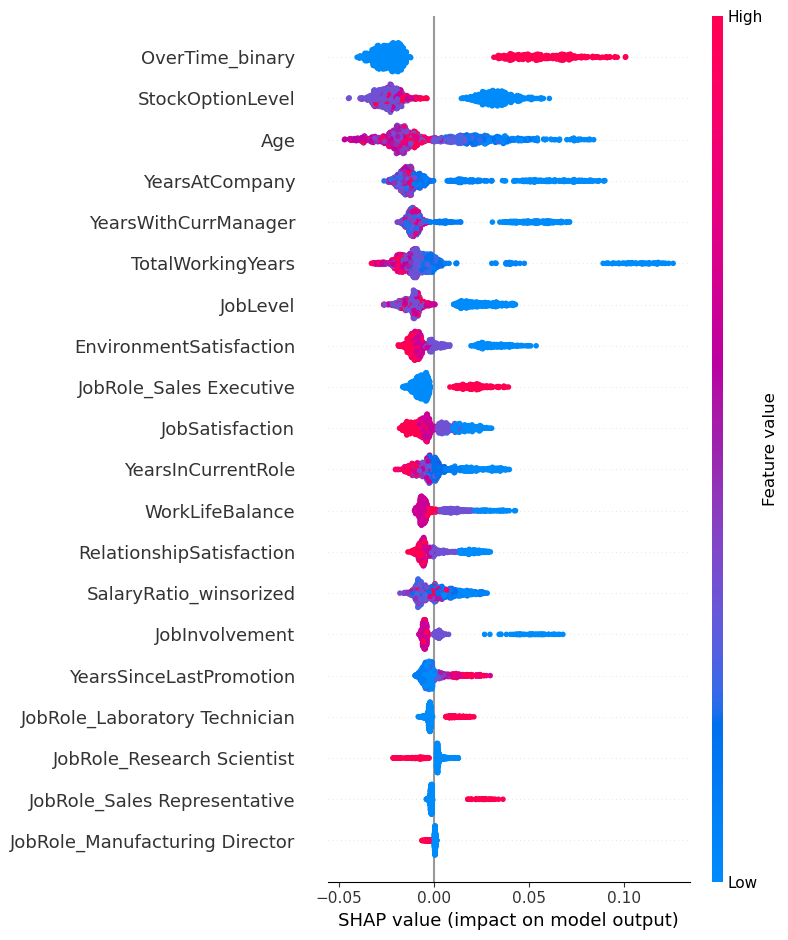


Generating SHAP dependence plot for: SalaryRatio_winsorized


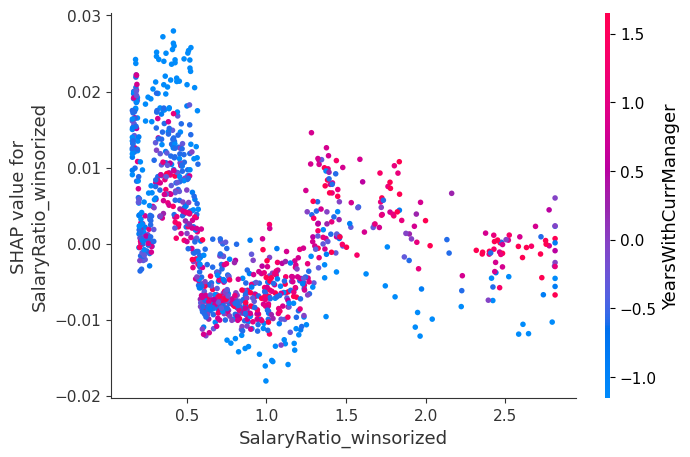


Generating SHAP dependence plot for: OverTime_binary


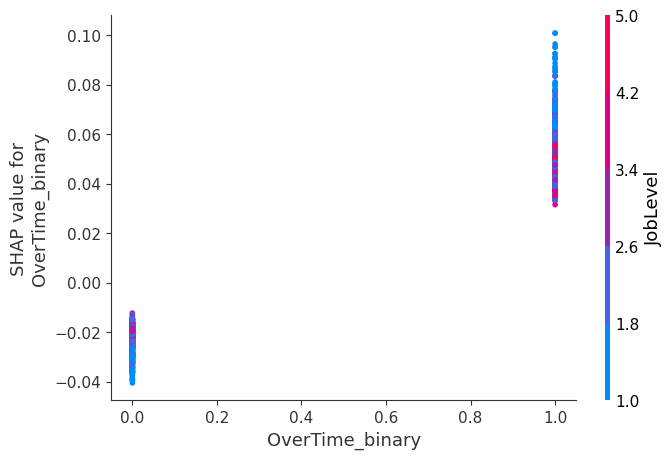


Generating SHAP dependence plot for: JobSatisfaction


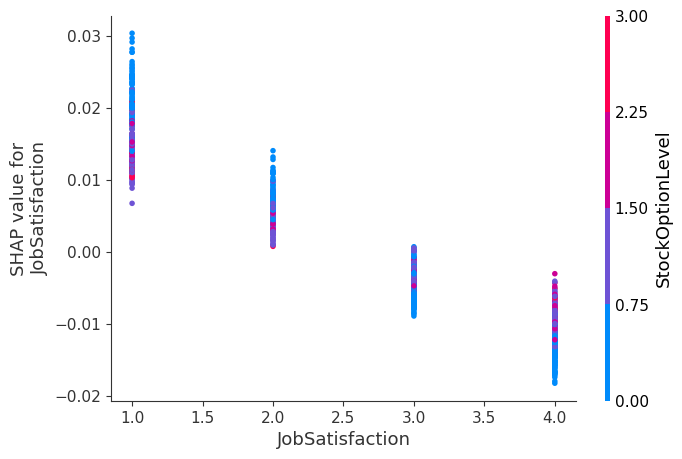


Generating SHAP dependence plot for: JobRole_Manager


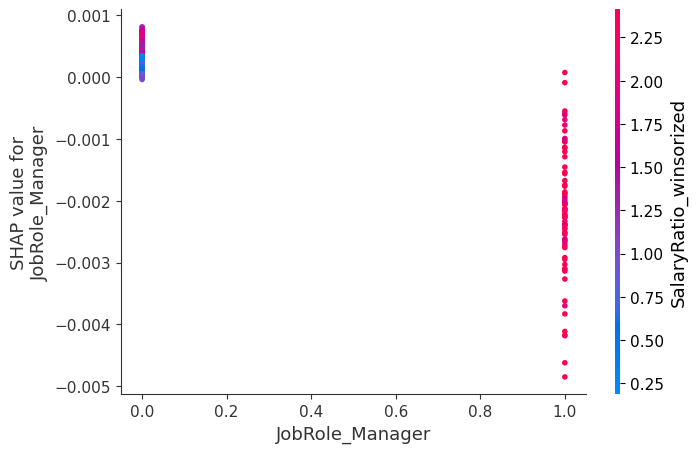

In [15]:
# =========================================================
# Section 8. SHAP-based validation
# =========================================================

import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split


# This section provides predictive validation only.
# SHAP values reflect predictive associations, not causal effects.

# ------------------------------------------
# 1. Build predictive dataset
# ------------------------------------------
predictor_features = X_scaled.copy()
predictor_features["SalaryRatio_winsorized"] = df["SalaryRatio_winsorized"].values

print("Predictor feature shape:", predictor_features.shape)
print("Outcome shape:", Y.shape)

# ------------------------------------------
# 2. Train/test split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    predictor_features,
    Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------
# 3. Fit predictive model
# ------------------------------------------
rf_clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

print("\nRandomForestClassifier fitted successfully.")

# ------------------------------------------
# 4. Predictive performance check
# ------------------------------------------
train_prob = rf_clf.predict_proba(X_train)[:, 1]
test_prob = rf_clf.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_prob)
test_auc = roc_auc_score(y_test, test_prob)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

# Optional classification report on test set
y_test_pred = rf_clf.predict(X_test)
print("\nClassification report on test set:")
print(classification_report(y_test, y_test_pred))

# ------------------------------------------
# 5. SHAP explanation
#    Use training data for SHAP interpretation
# ------------------------------------------
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_train)

print("\nRaw shap_values shape:", np.array(shap_values).shape)
print("X_train shape:", X_train.shape)

# For your SHAP version: (n_samples, n_features, n_classes)
shap_matrix = shap_values[:, :, 1]

print("Final shap_matrix shape:", shap_matrix.shape)

# ------------------------------------------
# 6. SHAP summary plot
# ------------------------------------------
print("\nGenerating SHAP summary plot...")
shap.summary_plot(shap_matrix, X_train)

# ------------------------------------------
# 7. SHAP dependence plots
# ------------------------------------------
    
for feature_name in [
    "SalaryRatio_winsorized",
    "OverTime_binary",
    "JobSatisfaction",
    "JobRole_Manager"
]:
    print(f"\nGenerating SHAP dependence plot for: {feature_name}")
    shap.dependence_plot(feature_name, shap_matrix, X_train)

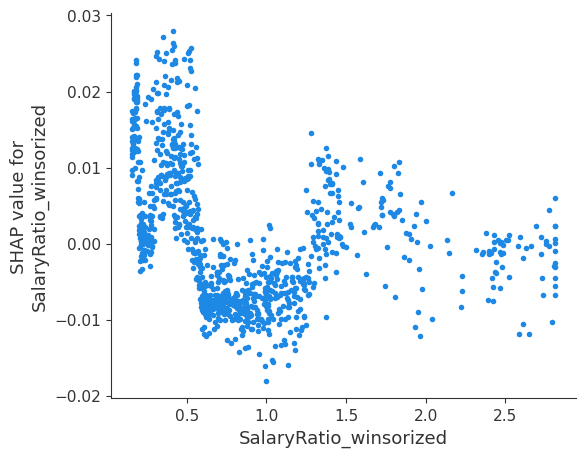

In [16]:
shap.dependence_plot(
    "SalaryRatio_winsorized",
    shap_matrix,
    X_train,
    interaction_index=None
)

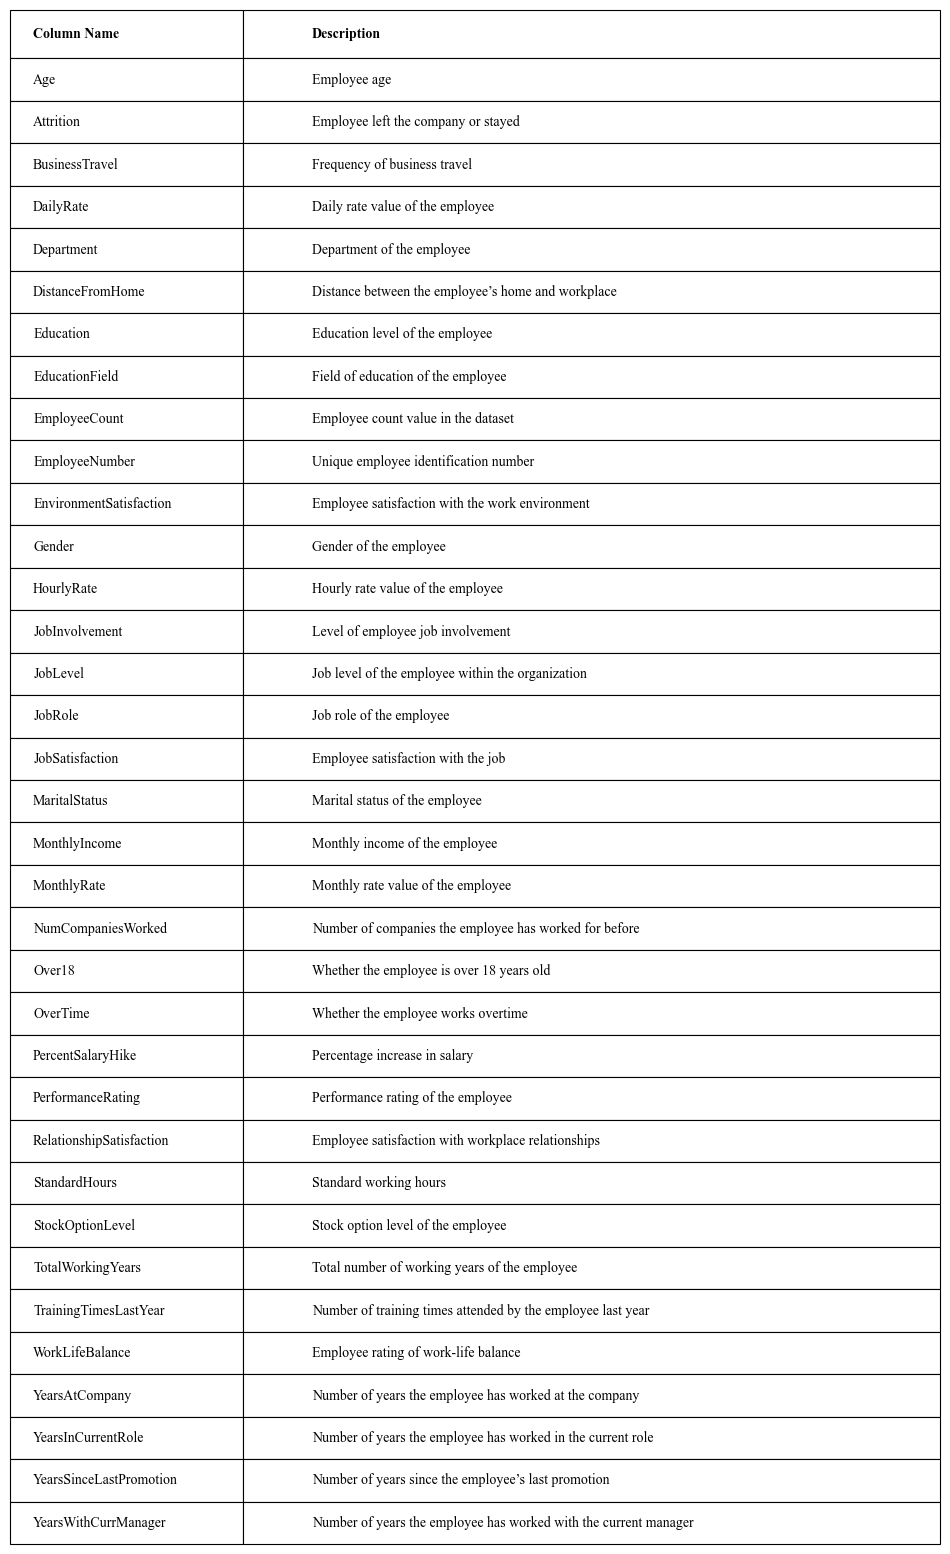

Saved as Appendix_A_variable_description.png


In [17]:
import matplotlib as mpl
from textwrap import fill

# Set font to Times New Roman
mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["font.size"] = 10

# -----------------------------
# Appendix A variable table data
# -----------------------------

data = [
    ("Age", "Employee age"),
    ("Attrition", "Employee left the company or stayed"),
    ("BusinessTravel", "Frequency of business travel"),
    ("DailyRate", "Daily rate value of the employee"),
    ("Department", "Department of the employee"),
    ("DistanceFromHome", "Distance between the employee’s home and workplace"),
    ("Education", "Education level of the employee"),
    ("EducationField", "Field of education of the employee"),
    ("EmployeeCount", "Employee count value in the dataset"),
    ("EmployeeNumber", "Unique employee identification number"),
    ("EnvironmentSatisfaction", "Employee satisfaction with the work environment"),
    ("Gender", "Gender of the employee"),
    ("HourlyRate", "Hourly rate value of the employee"),
    ("JobInvolvement", "Level of employee job involvement"),
    ("JobLevel", "Job level of the employee within the organization"),
    ("JobRole", "Job role of the employee"),
    ("JobSatisfaction", "Employee satisfaction with the job"),
    ("MaritalStatus", "Marital status of the employee"),
    ("MonthlyIncome", "Monthly income of the employee"),
    ("MonthlyRate", "Monthly rate value of the employee"),
    ("NumCompaniesWorked", "Number of companies the employee has worked for before"),
    ("Over18", "Whether the employee is over 18 years old"),
    ("OverTime", "Whether the employee works overtime"),
    ("PercentSalaryHike", "Percentage increase in salary"),
    ("PerformanceRating", "Performance rating of the employee"),
    ("RelationshipSatisfaction", "Employee satisfaction with workplace relationships"),
    ("StandardHours", "Standard working hours"),
    ("StockOptionLevel", "Stock option level of the employee"),
    ("TotalWorkingYears", "Total number of working years of the employee"),
    ("TrainingTimesLastYear", "Number of training times attended by the employee last year"),
    ("WorkLifeBalance", "Employee rating of work-life balance"),
    ("YearsAtCompany", "Number of years the employee has worked at the company"),
    ("YearsInCurrentRole", "Number of years the employee has worked in the current role"),
    ("YearsSinceLastPromotion", "Number of years since the employee’s last promotion"),
    ("YearsWithCurrManager", "Number of years the employee has worked with the current manager")
]

df = pd.DataFrame(data, columns=["Column Name", "Description"])

# Wrap long text so it fits inside the image
df["Description"] = df["Description"].apply(lambda x: fill(x, width=65))

# -----------------------------
# Create table image
# -----------------------------

fig_height = max(14, len(df) * 0.45)
fig, ax = plt.subplots(figsize=(12, fig_height))
ax.axis("off")

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.25, 0.75],
    loc="center"
)

# Basic style
table.auto_set_font_size(False)
table.set_fontsize(10)

# Style header and cells
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    if row == 0:
        cell.set_text_props(
            weight="bold",
            fontfamily="Times New Roman",
            fontsize=10
        )
        cell.set_height(0.04)
    else:
        cell.set_text_props(
            fontfamily="Times New Roman",
            fontsize=10
        )
        cell.set_height(0.035)

# Save image
plt.savefig(
    "Appendix_A_variable_description.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved as Appendix_A_variable_description.png")